## Evaluation of RobotAgent versions on different mission layouts

In [ ]:
# GROUP : 23
# DATE : 28.03.2025
# MEMBERS :
# - ZUO Yuxian
# - NADALIN	Marius
# - EL BARHICHI	Mohammed

### Imports & setup

In [1]:
from tqdm import tqdm
import sys
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append('./MAS')

from MAS.model import RobotMission

In [24]:
def run_model(model, max_steps):
    """
    Run the model once and return the score (Nb. steps to clean).
    """
    model.reset()
    nb_steps = 0
    terminated = False
    
    while not terminated:
        if nb_steps > max_steps:
            break
        model.step()
        nb_steps += 1
        terminated = model.is_mission_terminated()
    
    return nb_steps, terminated

def evaluate_model(model, N, max_steps, df=None):
    """
    Evaluate the model N times and return the average score (Nb. steps to clean).
    """
    avg_score = 0
    nb_terminated = 0
    
    for _ in tqdm(range(N)):
        score, terminated = run_model(model, max_steps)
        if terminated:
            avg_score += score
            nb_terminated += 1
        if df is not None:
            df.loc[len(df)] = [score, terminated, model.get_nb_sent_msgs_comm_1(), model.get_nb_sent_msgs_comm_2()]
        
    return avg_score / nb_terminated, nb_terminated / N

def show_results(df):
    """
    Show the results of the evaluation.
    """
    print("Average nb_steps (Nb. steps to clean):", f"{df['nb_steps'].mean():.2f}")
    print("Maximum nb_steps (Nb. steps to clean):",f"{ df['nb_steps'].max():.2f}")
    print("Minimum nb_steps (Nb. steps to clean):", f"{df['nb_steps'].min():.2f}")
    print("Percentage of terminated missions:", f"{df['terminated'].mean() * 100:.2f}", "%")
    print("Average number of messages sent by comm_1:", f"{df['nb_sent_msgs_comm_1'].mean():.2f}")
    print("Average number of messages sent by comm_2:", f"{df['nb_sent_msgs_comm_2'].mean():.2f}")
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    # Boxplot
    df['nb_steps'].plot(kind='box', title='Boxplot of Scores', ax=axes[0])
    
    # Histogram
    df['nb_steps'].plot(kind='hist', bins=50, title='Distribution of Scores', ax=axes[1])
    axes[1].set_xlabel('Number of Steps')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    

In [3]:
N = 1000
max_steps = 1000

### **Robots without communication** - Before applying "dropping after N steps"

In [ ]:
# Model stardard size (12x8) w. 6 robots (G:2 - Y:2 - R:2)
#                               12 wastes (G:6 - Y:3 - R:3)

model_no_comm_1 = RobotMission(robot_type="No communication",
                      nb_green_robots=2,
                      nb_yellow_robots=2,
                      nb_red_robots=2,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_no_comm_1, N, max_steps)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

In [ ]:
# Model stardard size (12x8) w. 3 robots (G:1 - Y:1 - R:1)
#                               12 wastes (G:6 - Y:3 - R:3)

model_no_comm_2 = RobotMission(robot_type="No communication",
                      nb_green_robots=1,
                      nb_yellow_robots=1,
                      nb_red_robots=1,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_no_comm_2, N, max_steps)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 100/100 [00:01<00:00, 79.96it/s]

Average Score : 101.15 steps
Average termination of mission : 100.00%


In [ ]:
# Model large size (24x16) w. 12 robots (G:4 - Y:4 - R:4)

model_no_comm_3 = RobotMission(robot_type="No communication",
                      nb_green_robots=4,
                      nb_yellow_robots=4,
                      nb_red_robots=4,
                      nb_green_wastes=10,
                      nb_yellow_wastes=7,
                      nb_red_wastes=5,
                      width=24,
                      height=16)

avg_score, avg_terminated = evaluate_model(model_no_comm_3, N, max_steps)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 100/100 [01:15<00:00,  1.32it/s]

Average Score : 153.00 steps
Average termination of mission : 6.00%


### **Robots without communication** - After applying "dropping after N steps"

In [4]:
# Model stardard size (12x8) w. 6 robots (G:2 - Y:2 - R:2)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_1_no_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_no_comm_1 = RobotMission(robot_type="No communication",
                      nb_green_robots=2,
                      nb_yellow_robots=2,
                      nb_red_robots=2,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_no_comm_1, N, max_steps, df_model_1_no_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:57<00:00,  8.54it/s]

Average Score : 85.04 steps
Average termination of mission : 61.20%


Average nb_steps (Nb. steps to clean): 440.43
Maximum nb_steps (Nb. steps to clean): 1001.00
Minimum nb_steps (Nb. steps to clean): 32.00
Percentage of terminated missions: 61.20 %
Average number of messages sent by comm_1: 0.00
Average number of messages sent by comm_2: 0.00


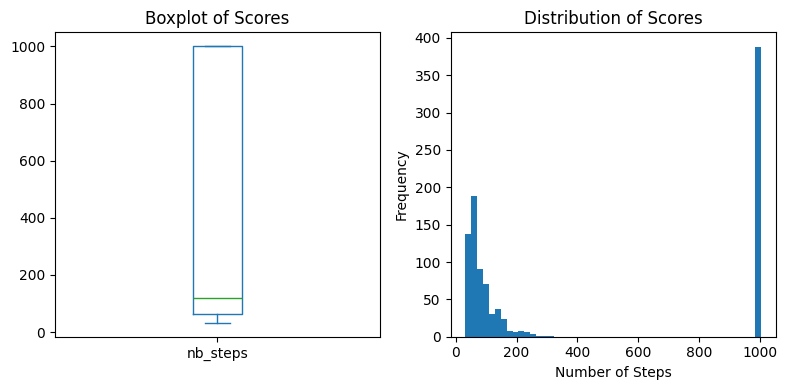

In [25]:
show_results(df_model_1_no_comm)
df_model_1_no_comm.to_csv('model_1_no_comm_no_drop.csv', index=False)

In [6]:
# Model stardard size (12x8) w. 3 robots (G:1 - Y:1 - R:1)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_2_no_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_no_comm_2 = RobotMission(robot_type="No communication",
                      nb_green_robots=1,
                      nb_yellow_robots=1,
                      nb_red_robots=1,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_no_comm_2, N, max_steps, df_model_2_no_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [00:15<00:00, 65.82it/s]

Average Score : 101.37 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 101.37
Maximum nb_steps (Nb. steps to clean): 226.00
Minimum nb_steps (Nb. steps to clean): 52.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 0.00
Average number of messages sent by comm_2: 0.00


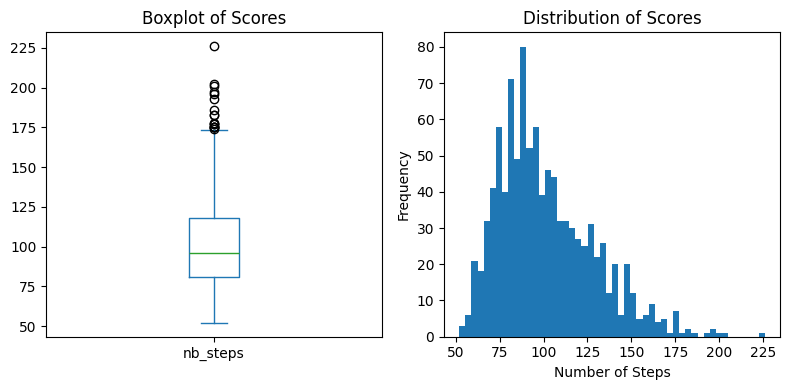

In [26]:
show_results(df_model_2_no_comm)
df_model_2_no_comm.to_csv('model_2_no_comm_no_drop.csv', index=False)

In [8]:
# Model large size (24x16) w. 12 robots (G:4 - Y:4 - R:4)

df_model_3_no_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_no_comm_3 = RobotMission(robot_type="No communication",
                      nb_green_robots=4,
                      nb_yellow_robots=4,
                      nb_red_robots=4,
                      nb_green_wastes=10,
                      nb_yellow_wastes=7,
                      nb_red_wastes=5,
                      width=24,
                      height=16)

avg_score, avg_terminated = evaluate_model(model_no_comm_3, N, max_steps, df_model_3_no_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [12:04<00:00,  1.38it/s]

Average Score : 351.23 steps
Average termination of mission : 16.30%


Average nb_steps (Nb. steps to clean): 895.09
Maximum nb_steps (Nb. steps to clean): 1001.00
Minimum nb_steps (Nb. steps to clean): 89.00
Percentage of terminated missions: 16.30 %
Average number of messages sent by comm_1: 0.00
Average number of messages sent by comm_2: 0.00


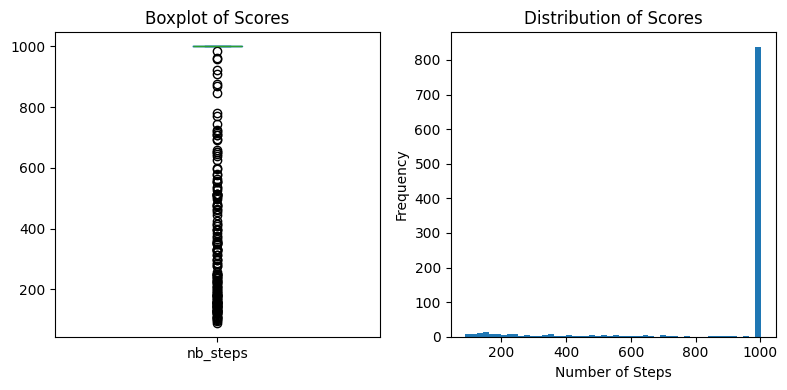

In [27]:
show_results(df_model_3_no_comm)
df_model_3_no_comm.to_csv('model_3_no_comm_no_drop.csv', index=False)

### **Robots with communication**

In [10]:
# Model stardard size (12x8) w. 6 robots (G:2 - Y:2 - R:2)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_1_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_with_comm_1 = RobotMission(robot_type="With communication",
                      nb_green_robots=2,
                      nb_yellow_robots=2,
                      nb_red_robots=2,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_with_comm_1, N, max_steps, df_model_1_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [00:18<00:00, 55.48it/s]

Average Score : 67.16 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 67.16
Maximum nb_steps (Nb. steps to clean): 132.00
Minimum nb_steps (Nb. steps to clean): 35.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 21.89
Average number of messages sent by comm_2: 0.00


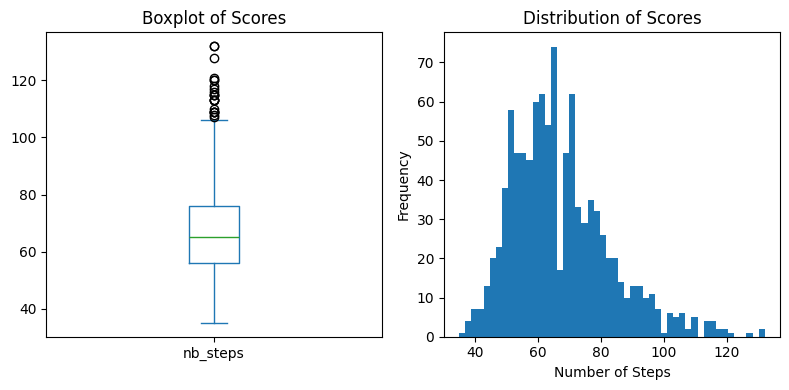

In [28]:
show_results(df_model_1_comm)
df_model_1_comm.to_csv('model_1_comm_1_only.csv', index=False)

In [12]:
# Model stardard size (12x8) w. 3 robots (G:1 - Y:1 - R:1)
#                               12 wastes (G:6 - Y:3 - R:3)

df_model_2_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_with_comm_2 = RobotMission(robot_type="With communication",
                      nb_green_robots=1,
                      nb_yellow_robots=1,
                      nb_red_robots=1,
                      nb_green_wastes=6,
                      nb_yellow_wastes=3,
                      nb_red_wastes=3,
                      width=12,
                      height=8)

avg_score, avg_terminated = evaluate_model(model_with_comm_2, N, max_steps, df_model_2_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [00:16<00:00, 60.11it/s]

Average Score : 99.41 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 99.41
Maximum nb_steps (Nb. steps to clean): 205.00
Minimum nb_steps (Nb. steps to clean): 50.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 0.00
Average number of messages sent by comm_2: 0.00


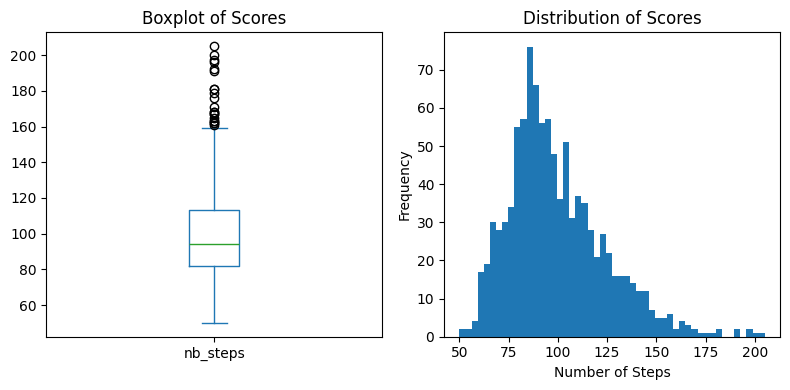

In [29]:
show_results(df_model_2_comm)
df_model_2_comm.to_csv('model_2_comm_1_only.csv', index=False)

In [14]:
# Model large size (24x16) w. 12 robots (G:4 - Y:4 - R:4)

df_model_3_comm = pd.DataFrame(columns=['nb_steps', 'terminated', 'nb_sent_msgs_comm_1', 'nb_sent_msgs_comm_2'])

model_with_comm_3 = RobotMission(robot_type="With communication",
                      nb_green_robots=4,
                      nb_yellow_robots=4,
                      nb_red_robots=4,
                      nb_green_wastes=10,
                      nb_yellow_wastes=7,
                      nb_red_wastes=5,
                      width=24,
                      height=16)

avg_score, avg_terminated = evaluate_model(model_with_comm_3, N, max_steps, df_model_3_comm)
print(f'Average Score : {avg_score:.2f} steps')
print(f'Average termination of mission : {avg_terminated:.2%}')

100%|██████████| 1000/1000 [01:58<00:00,  8.42it/s]

Average Score : 164.70 steps
Average termination of mission : 100.00%


Average nb_steps (Nb. steps to clean): 164.70
Maximum nb_steps (Nb. steps to clean): 363.00
Minimum nb_steps (Nb. steps to clean): 86.00
Percentage of terminated missions: 100.00 %
Average number of messages sent by comm_1: 131.49
Average number of messages sent by comm_2: 0.00


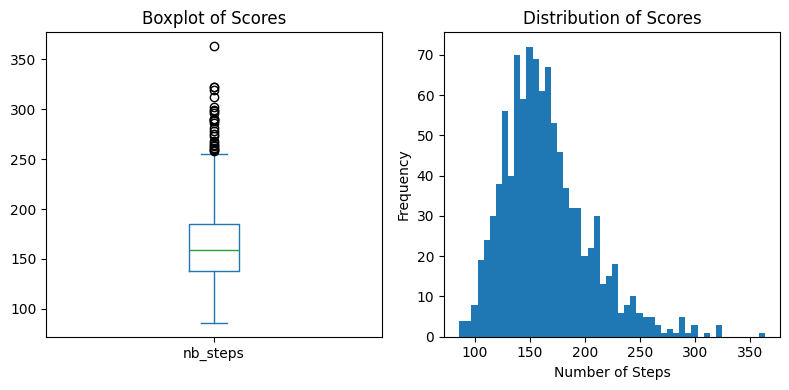

In [30]:
show_results(df_model_3_comm)
df_model_3_comm.to_csv('model_3_comm_1_only.csv', index=False)